In [ ]:
#Setup

# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression, LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.neighbors import KNeighborsClassifier, KNeighborsRegressor
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, mean_squared_error, r2_score
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
import xgboost as xgb
from sklearn.model_selection import GridSearchCV
from sklearn.pipeline import Pipeline

# Load the dataset

file_2011 = "1NhbZdHaXdnfmOv_FzXzfCp5x5eokQpLk"
file_2012 = "1tXLzWwXMztGfeTHXdOkMDuRrqmIJfMpA"
file_2013 = "1Zr7dMPuYrqkkaUFEQF60kRdo3Sv93iCC"
file_2014 = "1j5pLQC8dAlALsWBoPEiaRK1Go1Lff7px"
file_2015 = "1_Qn-_48KBHsF0ASMM3SsF8kzVxwy4uUz"

# Charger tous les fichiers
df_2011 = pd.read_csv(f"https://drive.google.com/uc?id={file_2011}")
df_2012 = pd.read_csv(f"https://drive.google.com/uc?id={file_2012}")
df_2013 = pd.read_csv(f"https://drive.google.com/uc?id={file_2013}")
df_2014 = pd.read_csv(f"https://drive.google.com/uc?id={file_2014}")
df_2015 = pd.read_csv(f"https://drive.google.com/uc?id={file_2015}")

# Merger tout
#df = pd.concat([df_2011, df_2012, df_2013, df_2014, df_2015], ignore_index=True)



url = f"https://drive.google.com/uc?id={file_2011}"

df = pd.read_csv(url)
# Merger tout
df = pd.concat([df_2011, df_2012, df_2013, df_2014, df_2015], ignore_index=True)
# Afficher les premières lignes
print(df)

           AT      AP      AH    AFDP    GTEP     TIT     TAT     TEY     CDP  \
0      4.5878  1018.7  83.675  3.5758  23.979  1086.2  549.83  134.67  11.898   
1      4.2932  1018.3  84.235  3.5709  23.951  1086.1  550.05  134.67  11.892   
2      3.9045  1018.4  84.858  3.5828  23.990  1086.5  550.19  135.10  12.042   
3      3.7436  1018.3  85.434  3.5808  23.911  1086.5  550.17  135.03  11.990   
4      3.7516  1017.8  85.182  3.5781  23.917  1085.9  550.00  134.67  11.910   
...       ...     ...     ...     ...     ...     ...     ...     ...     ...   
36728  3.6268  1028.5  93.200  3.1661  19.087  1037.0  541.59  109.08  10.411   
36729  4.1674  1028.6  94.036  3.1923  19.016  1037.6  542.28  108.79  10.344   
36730  5.4820  1028.5  95.219  3.3128  18.857  1038.0  543.48  107.81  10.462   
36731  5.8837  1028.7  94.200  3.9831  23.563  1076.9  550.11  131.41  11.771   
36732  6.0392  1028.8  94.547  3.8752  22.524  1067.9  548.23  125.41  11.462   

             CO      NOX  


# Dataset Analysis

In [ ]:
# Number of columns/rows, number of values, variables definition

print("Nombre de colonnes :", df.shape[1])
print("Nombre de lignes :", df.shape[0])
print("Nombre de valeurs :", df.size)
print("Type de data:\n",df.dtypes)

Nombre de colonnes : 11
Nombre de lignes : 36733
Nombre de valeurs : 404063
Type de data:
 AT      float64
AP      float64
AH      float64
AFDP    float64
GTEP    float64
TIT     float64
TAT     float64
TEY     float64
CDP     float64
CO      float64
NOX     float64
dtype: object


In [ ]:
# Quality

print("Statistiques\n", df.describe())
print("\nValeurs manquantes :\n", df.isnull().sum())
print("\nDoublons :", df.duplicated().sum())

Statistiques
                  AT            AP            AH          AFDP          GTEP  \
count  36733.000000  36733.000000  36733.000000  36733.000000  36733.000000   
mean      17.712726   1013.070165     77.867015      3.925518     25.563801   
std        7.447451      6.463346     14.461355      0.773936      4.195957   
min       -6.234800    985.850000     24.085000      2.087400     17.698000   
25%       11.781000   1008.800000     68.188000      3.355600     23.129000   
50%       17.801000   1012.600000     80.470000      3.937700     25.104000   
75%       23.665000   1017.000000     89.376000      4.376900     29.061000   
max       37.103000   1036.600000    100.200000      7.610600     40.716000   

                TIT           TAT           TEY           CDP            CO  \
count  36733.000000  36733.000000  36733.000000  36733.000000  36733.000000   
mean    1081.428084    546.158517    133.506404     12.060525      2.372468   
std       17.536373      6.842360    

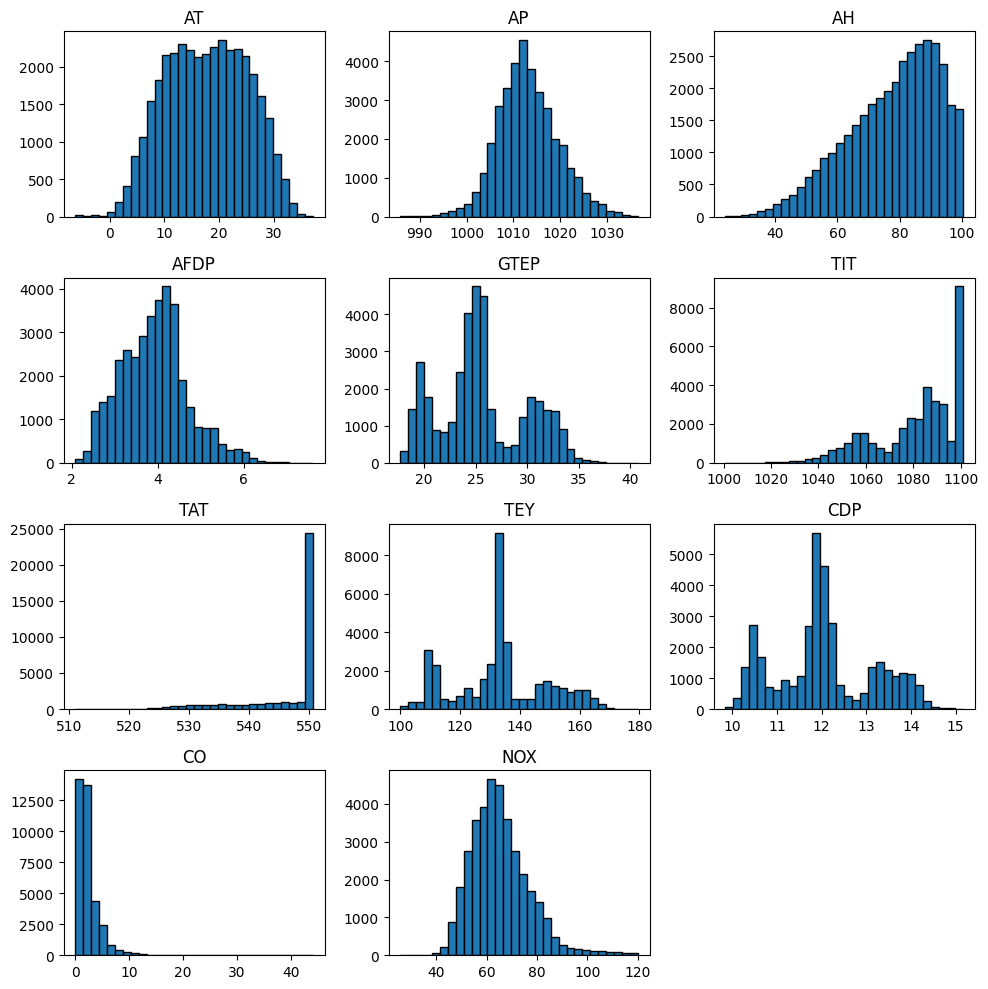

In [ ]:
#Visualisation

num_columns = df.shape[1]
num_rows = 4
num_cols = 3

fig, axes = plt.subplots(num_rows, num_cols, figsize=(10, 10))
axes = axes.flatten()
for i, col in enumerate(df.columns):
    axes[i].hist(df[col], bins=30, edgecolor='k')
    axes[i].set_title(col)
    axes[i].set_xlabel('')
    axes[i].set_ylabel('')
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

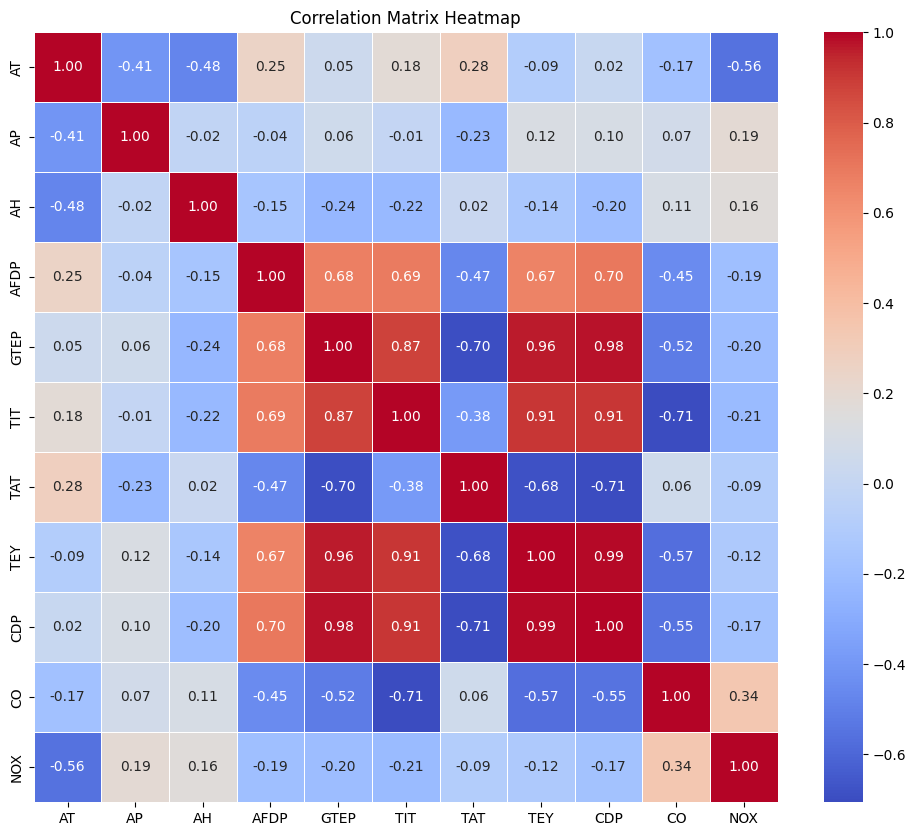

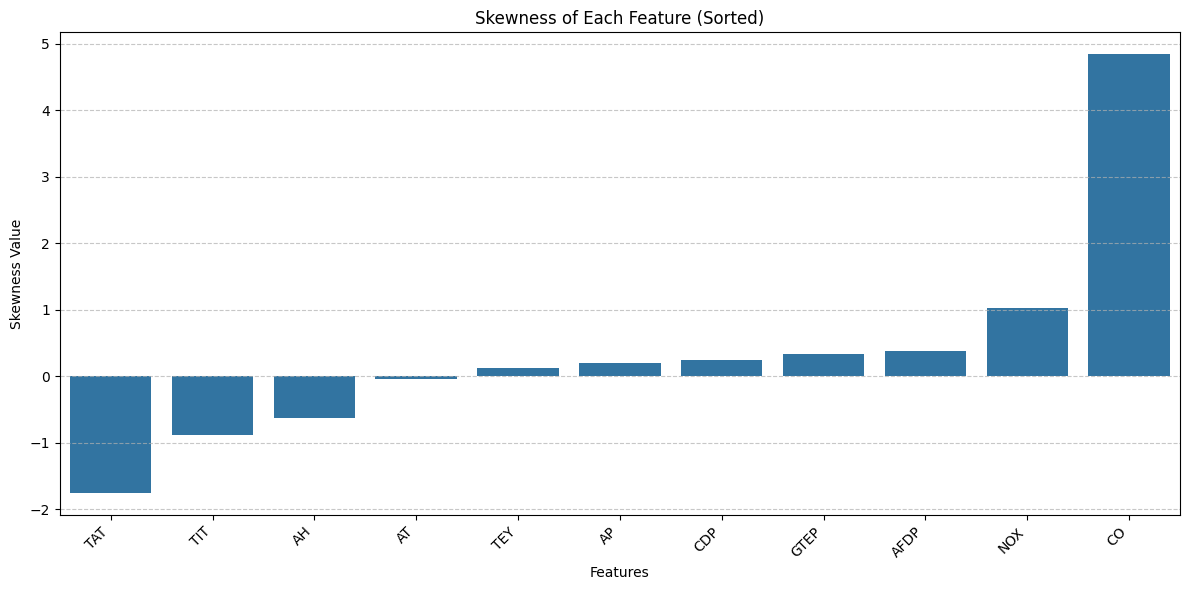

In [ ]:
# Correlation Analysis

correlation_matrix = df.corr()
plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title('Correlation Matrix Heatmap')
plt.show()

#Data balance

skewness_values = df.skew()
skewness_values_sorted = skewness_values.sort_values(ascending=True)
plt.figure(figsize=(12, 6))
sns.barplot(x=skewness_values_sorted.index, y=skewness_values_sorted.values)
plt.title('Skewness of Each Feature (Sorted)')
plt.xlabel('Features')
plt.ylabel('Skewness Value')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

# Data pre-processing

In [ ]:
#Duplicates management

duplicates_count = df.duplicated().sum()

print(f"Number of duplicate rows found: {duplicates_count}")

if duplicates_count > 0:
    print("\n--- Handling Duplicate Rows ---")
    df_no_duplicates = df.drop_duplicates()
    df_no_duplicates.shape
    print("Number of duplicate rows after dropping:\n", df_no_duplicates.duplicated().sum())
else:
    print("\nNo duplicate rows found in the dataset. No action needed for duplicates.")

Number of duplicate rows found: 7

--- Handling Duplicate Rows ---
Number of duplicate rows after dropping:
 0


In [ ]:
#Inconsistencies and Missing values management

print("\n--- Verification and management of data inconsistencies ---")

initial_missing_count = df.isnull().sum().sum()
print(f"Number of missing values : {initial_missing_count}")

df_cleaned = df.copy()
newly_missing_count = 0
for column in df_cleaned.columns:
    original_nans = df_cleaned[column].isnull().sum()
    df_cleaned[column] = pd.to_numeric(df_cleaned[column], errors='coerce')
    newly_introduced_nans = df_cleaned[column].isnull().sum() - original_nans
    if newly_introduced_nans > 0:
        print(f"  Incoherences found in '{column}': {newly_introduced_nans} converted to NaN.")
        newly_missing_count += newly_introduced_nans

if newly_missing_count > 0:
    print(f"Total number of incoherences converted : {newly_missing_count}")
else:
    print("No data type incoherence.")

total_missing_after_coercion = df_cleaned.isnull().sum().sum()

if total_missing_after_coercion > 0:
    print(f"\n--- Managment of incoherences and missing values ---")
    print(f"Total number of missing values ​​(initial + after consistency): {total_missing_after_coercion}")
    df = df_cleaned.dropna()
    print("Lines containing missing values ​​or inconsistencies have been removed")
    print("DataFrame format after row deletion:", df.shape)
else:
    print("\nNO incoherence or missing value in the dataset.")

print("Data types after verification and management of data inconsistencies :\n", df.dtypes)


--- Verification and management of data inconsistencies ---
Number of missing values : 0
No data type incoherence.

NO incoherence or missing value in the dataset.
Data types after verification and management of data inconsistencies :
 AT      float64
AP      float64
AH      float64
AFDP    float64
GTEP    float64
TIT     float64
TAT     float64
TEY     float64
CDP     float64
CO      float64
NOX     float64
dtype: object


In [ ]:
#Train/Split & Scale

common_features = df.drop(['NOX', 'CO'], axis=1)

y_NOX = df['NOX']
y_CO = df['CO']

# --- Train-Test Split for NOX ---
X_train_NOX_raw, X_test_NOX_raw, y_train_NOX, y_test_NOX = train_test_split(common_features, y_NOX, test_size=0.20, random_state=42)
scaler_NOX = StandardScaler()
X_train_NOX = scaler_NOX.fit_transform(X_train_NOX_raw)
X_test_NOX = scaler_NOX.transform(X_test_NOX_raw)

print("--- NOX Model Split & Scaling ---")
print("Shape of X_train_NOX:", X_train_NOX.shape)
print("Shape of X_test_NOX:", X_test_NOX.shape)
print("Shape of y_train_NOX:", y_train_NOX.shape)
print("Shape of y_test_NOX:", y_test_NOX.shape)

# --- Train-Test Split for CO ---
X_train_CO_raw, X_test_CO_raw, y_train_CO, y_test_CO = train_test_split(common_features, y_CO, test_size=0.20, random_state=42)
scaler_CO = StandardScaler()
X_train_CO = scaler_CO.fit_transform(X_train_CO_raw)
X_test_CO = scaler_CO.transform(X_test_CO_raw)

print("\n--- CO Model Split & Scaling ---")
print("Shape of X_train_CO:", X_train_CO.shape)
print("Shape of X_test_CO:", X_test_CO.shape)
print("Shape of y_train_CO:", y_train_CO.shape)
print("Shape of y_test_CO:", y_test_CO.shape)


--- NOX Model Split & Scaling ---
Shape of X_train_NOX: (29386, 9)
Shape of X_test_NOX: (7347, 9)
Shape of y_train_NOX: (29386,)
Shape of y_test_NOX: (7347,)

--- CO Model Split & Scaling ---
Shape of X_train_CO: (29386, 9)
Shape of X_test_CO: (7347, 9)
Shape of y_train_CO: (29386,)
Shape of y_test_CO: (7347,)


In [ ]:
models_and_params = {
    "Ridge": (
        Ridge(),
        {"model__alpha": [0.1, 1.0, 10.0]}
    ),
    "Lasso": (
        Lasso(),
        {"model__alpha": [0.001, 0.01, 0.1], "model__max_iter": [20000]}
    ),
    "RandomForest": (
        RandomForestRegressor(random_state=42),
        {"model__n_estimators": [100, 200], "model__max_features": ["sqrt", "log2"]}
    ),
    "GradientBoosting": (
        GradientBoostingRegressor(random_state=42),
        {"model__n_estimators": [100, 200], "model__learning_rate": [0.01, 0.1], "model__max_depth": [3, 4]}
    ),
    "XGBoost": (
        xgb.XGBRegressor(random_state=42),
        {"model__n_estimators": [100, 200], "model__learning_rate": [0.01, 0.1], "model__max_depth": [3, 5]}
    ),
    "KNN": (
        KNeighborsRegressor(),
        {"model__n_neighbors": [3, 5, 7], "model__weights": ["uniform", "distance"]}
    ),
}

In [ ]:
def train_all_models(X_train, y_train, X_test, y_test, target_name):
    results = []

    for name, (model, params) in models_and_params.items():
        print(f"\n{name} for {target_name}")

        pipe = Pipeline([
            ("scaler", StandardScaler()),
            ("model", model)
        ])

        grid = GridSearchCV(
            pipe,
            params,
            scoring="r2",
            cv=5,
            n_jobs=-1,
            verbose=1
        )

        grid.fit(X_train, y_train)
        best_model = grid.best_estimator_

        # Test performance
        y_pred = best_model.predict(X_test)
        R2 = r2_score(y_test, y_pred)
        MSE = np.sqrt(mean_squared_error(y_test, y_pred))

        print(f"Best params: {grid.best_params_}")
        print(f"Test R2: {R2:.4f}  |  MSE: {MSE:.4f}")

        results.append((name, best_model, R2, MSE))

    return results

In [ ]:
results_nox = train_all_models(X_train_NOX, y_train_NOX, X_test_NOX, y_test_NOX, "NOX")


Ridge for NOX
Fitting 5 folds for each of 3 candidates, totalling 15 fits
Best params: {'model__alpha': 0.1}
Test R2: 0.4947  |  MSE: 8.1832

Lasso for NOX
Fitting 5 folds for each of 3 candidates, totalling 15 fits
Best params: {'model__alpha': 0.001, 'model__max_iter': 20000}
Test R2: 0.4947  |  MSE: 8.1825

RandomForest for NOX
Fitting 5 folds for each of 4 candidates, totalling 20 fits
Best params: {'model__max_features': 'sqrt', 'model__n_estimators': 200}
Test R2: 0.8765  |  MSE: 4.0450

GradientBoosting for NOX
Fitting 5 folds for each of 8 candidates, totalling 40 fits
Best params: {'model__learning_rate': 0.1, 'model__max_depth': 4, 'model__n_estimators': 200}
Test R2: 0.8143  |  MSE: 4.9603

XGBoost for NOX
Fitting 5 folds for each of 8 candidates, totalling 40 fits
Best params: {'model__learning_rate': 0.1, 'model__max_depth': 5, 'model__n_estimators': 200}
Test R2: 0.8411  |  MSE: 4.5893

KNN for NOX
Fitting 5 folds for each of 6 candidates, totalling 30 fits
Best params: 

In [ ]:
results_co = train_all_models(X_train_CO, y_train_CO, X_test_CO, y_test_CO, "CO")


Ridge for CO
Fitting 5 folds for each of 3 candidates, totalling 15 fits
Best params: {'model__alpha': 0.1}
Test R2: 0.5566  |  MSE: 1.5527

Lasso for CO
Fitting 5 folds for each of 3 candidates, totalling 15 fits
Best params: {'model__alpha': 0.001, 'model__max_iter': 20000}
Test R2: 0.5564  |  MSE: 1.5531

RandomForest for CO
Fitting 5 folds for each of 4 candidates, totalling 20 fits


In [ ]:
def print_results(results):
    print(f"{'Model':20} | {'R2':8} | {'RMSE':8}")
    print("-"*50)

    for name, _, r2, rmse in sorted(results, key=lambda x: x[2], reverse=True):
        print(f"{name:20} | {r2:8.4f} | {rmse:8.4f}")



In [ ]:
print("Comparison for NOX")
print_results(results_nox)
print("\nComparison for CO")
print_results(results_co)


In [ ]:
from sklearn.decomposition import PCA

pca_pipe_nox = Pipeline([
    ("scaler", StandardScaler()),
    ("pca", PCA(n_components=5)),
    ("model", KNeighborsRegressor())
])

pca_pipe_nox.fit(X_train_NOX, y_train_NOX)
pca_pred_nox = pca_pipe_nox.predict(X_test_NOX)

print("\nPCA model results for NOX:")
print("R2:", r2_score(y_test_NOX, pca_pred_nox))
print("RMSE:", np.sqrt(mean_squared_error(y_test_NOX, pca_pred_nox)))


In [ ]:
pca_pipe_co = Pipeline([
    ("scaler", StandardScaler()),
    ("pca", PCA(n_components=5)),
    ("model", KNeighborsRegressor())
])

pca_pipe_co.fit(X_train_CO, y_train_CO)
pca_pred_co = pca_pipe_co.predict(X_test_CO)

print("\nPCA model results for CO:")
print("R2:", r2_score(y_test_CO, pca_pred_co))
print("RMSE:", np.sqrt(mean_squared_error(y_test_CO, pca_pred_co)))


In [ ]:
def diagnose_model(model, X_train, y_train, X_test, y_test, name="Model"):
    y_pred_train = model.predict(X_train)
    y_pred_test = model.predict(X_test)

    r2_train = r2_score(y_train, y_pred_train)
    r2_test = r2_score(y_test, y_pred_test)

    print(f"\n=== Diagnostic for {name} ===")
    print(f"Train R2: {r2_train:.4f}")
    print(f"Test R2 : {r2_test:.4f}")

    if r2_train - r2_test > 0.15:
        print("Overfitting detected.")
    elif r2_test < 0.3:
        print("Underfitting detected.")
    else:
        print("Balanced model (no strong overfitting).")

In [ ]:
best_nox = max(results_nox, key=lambda x: x[2])
diagnose_model(best_nox[1], X_train_NOX, y_train_NOX, X_test_NOX, y_test_NOX, "Best NOX Model")
best_co = max(results_co, key=lambda x: x[2])
diagnose_model(best_co[1], X_train_CO, y_train_CO, X_test_CO, y_test_CO, "Best CO Model")

In [ ]:
from sklearn.model_selection import learning_curve

def plot_learning_curve(model, X, y, title):
    train_sizes, train_scores, test_scores = learning_curve(
        model, X, y, cv=5, scoring="r2", n_jobs=-1,
        train_sizes=np.linspace(0.1, 1.0, 10)
    )

    plt.figure(figsize=(8,5))
    plt.plot(train_sizes, train_scores.mean(axis=1), "o-", label="Training score")
    plt.plot(train_sizes, test_scores.mean(axis=1), "o-", label="Validation score")
    plt.title(title)
    plt.xlabel("Training size")
    plt.ylabel("R2")
    plt.legend()
    plt.grid(True)
    plt.show()

In [ ]:
plot_learning_curve(best_nox[1], X_train_NOX, y_train_NOX, "Learning Curve - NOX")
plot_learning_curve(best_co[1], X_train_CO, y_train_CO, "Learning Curve - CO")

In [ ]:
def get_top_models(results, top_n=3):
    sorted_models = sorted(results, key=lambda x: x[2], reverse=True)
    return sorted_models[:top_n]

In [ ]:
from sklearn.ensemble import VotingRegressor

def build_voting_ensemble(top_models, X_train, y_train, X_test, y_test, target_name, results_list):
    estimators = [(name, model) for name, model, _, _ in top_models]

    voting = VotingRegressor(estimators)
    voting.fit(X_train, y_train)

    preds = voting.predict(X_test)
    r2 = r2_score(y_test, preds)
    rmse = np.sqrt(mean_squared_error(y_test, preds))

    print(f"\nVoting Ensemble results {target_name}:")
    print(f"R2 = {r2:.4f} : RMSE = {rmse:.4f}")

    results_list.append(("Voting", voting, r2, rmse))
    return voting


In [ ]:
results_list = []
top_nox = get_top_models(results_nox)
voting_nox = build_voting_ensemble(top_nox, X_train_NOX, y_train_NOX, X_test_NOX, y_test_NOX, "NOX", results_nox)

In [ ]:
top_co = get_top_models(results_co)
voting_co = build_voting_ensemble(top_co, X_train_CO, y_train_CO, X_test_CO, y_test_CO, "CO", results_co)

In [ ]:
from sklearn.ensemble import StackingRegressor

def build_stacking(top_models, X_train, y_train, X_test, y_test, target_name, results_list):
    estimators = [(name, model) for name, model, _, _ in top_models]

    stack = StackingRegressor(
        estimators=estimators,
        final_estimator=Ridge(),
        n_jobs=-1
    )

    stack.fit(X_train, y_train)
    preds = stack.predict(X_test)

    r2 = r2_score(y_test, preds)
    rmse = np.sqrt(mean_squared_error(y_test, preds))

    print(f"\nStacking Ensemble results for {target_name}:")
    print(f"R2 = {r2:.4f} | RMSE = {rmse:.4f}")
    results_list.append(("Stacking", stack, r2, rmse))

    return stack


In [ ]:
stacking_nox = build_stacking(top_nox, X_train_NOX, y_train_NOX, X_test_NOX, y_test_NOX, "NOX", results_nox)

In [ ]:
stacking_co = build_stacking(top_co, X_train_CO, y_train_CO, X_test_CO, y_test_CO, "CO", results_co)

In [ ]:
def conclude(results, variable):
    best = max(results, key=lambda x: x[2])
    print(f"\nBest Model for {variable}: {best[0]}")
    print(f"R2 = {best[2]:.4f}")
    print(f"RMSE = {best[3]:.4f}")
    print("\nConclusion:")
    print(f"The best model for {variable} is {best[0]}, with the highest R2 and lowest RMSE. ")


In [ ]:
conclude(results_nox, "NOX")
conclude(results_co, "CO")
